<a href="https://colab.research.google.com/github/Saifullah785/machine-learning-engineer-roadmap/blob/main/Lecture_32_Binning_Discretization_Quantile_KMeans_Binning/Lecture_32_Binning_Discretization_Quantile_KMeans_Binning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Binning and Binarization**

**Discretization**

**Quantile Binning**

**KMeans Binning**

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np

In [2]:
# Import visualization and machine learning libraries
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [3]:
# Load the dataset
df = pd.read_csv('/content/train.csv',usecols=['Age','Fare','Survived'])

In [4]:
# Drop rows with missing values
df.dropna(inplace=True)

In [5]:
# Display the shape of the dataframe
df.shape

(714, 3)

In [6]:
# Display the first 5 rows of the dataframe
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
# Separate features (X) and target (y)
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [8]:
# Split data into training and testing sets
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [27]:
# Display the head of the training features
X_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [10]:
# Initialize a Decision Tree Classifier
clf = DecisionTreeClassifier()

In [11]:
# Train the classifier and make predictions
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [12]:
# Calculate and display the accuracy score
accuracy_score(y_test,y_pred)

0.6293706293706294

In [13]:
# Calculate and display the mean cross-validation score
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6289123630672926)

In [14]:
# Initialize KBinsDiscretizer for age and fare using quantile strategy
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

In [15]:
# Create a ColumnTransformer for applying discretizers
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [16]:
# Apply the ColumnTransformer to the training and testing data
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

In [17]:
# Display the bin edges for age
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [18]:
# Display the bin edges for age (duplicate cell)
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [19]:
# Create a DataFrame with original and transformed data
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [20]:
# Add labels for age and fare bins to the output DataFrame
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())

In [21]:
# Display a random sample of the output DataFrame
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
583,36.0,10.0,40.1250,11.0,"(35.0, 38.0]","(31.275, 51.479]"
659,58.0,14.0,113.2750,14.0,"(54.0, 80.0]","(108.9, 512.329]"
251,29.0,7.0,10.4625,4.0,"(28.0, 30.0]","(8.158, 10.5]"
44,19.0,3.0,7.8792,2.0,"(16.0, 19.0]","(7.775, 7.896]"
21,34.0,9.0,13.0000,6.0,"(32.0, 35.0]","(10.5, 13.0]"


In [22]:
# Train a Decision Tree Classifier on the transformed data and make predictions
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [23]:
# Calculate and display the accuracy score of the classifier on transformed data
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [24]:
# Apply the ColumnTransformer to the full dataset and calculate cross-validation score
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6344287949921752)

In [25]:
# Define a function to discretize data and visualize results
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()

0.6359154929577464


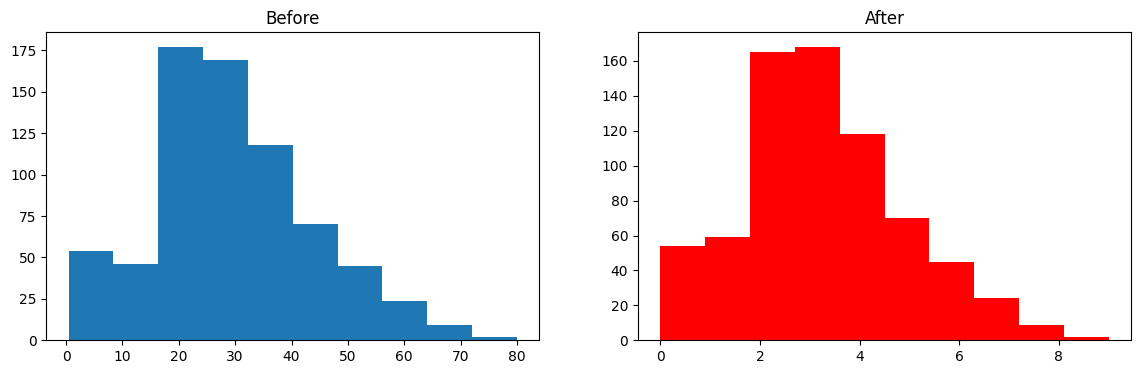

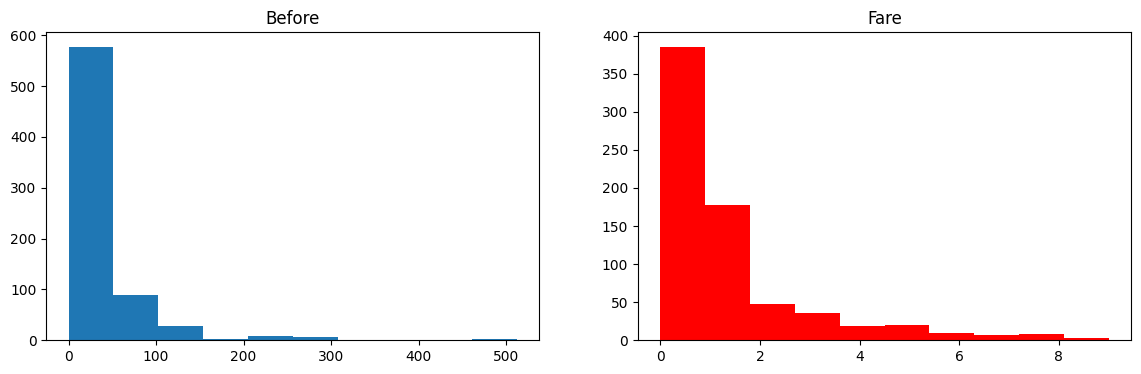

In [26]:
# Call the discretize function with 10 bins and 'kmeans' strategy
discretize(10,'kmeans')

0.6289319248826291


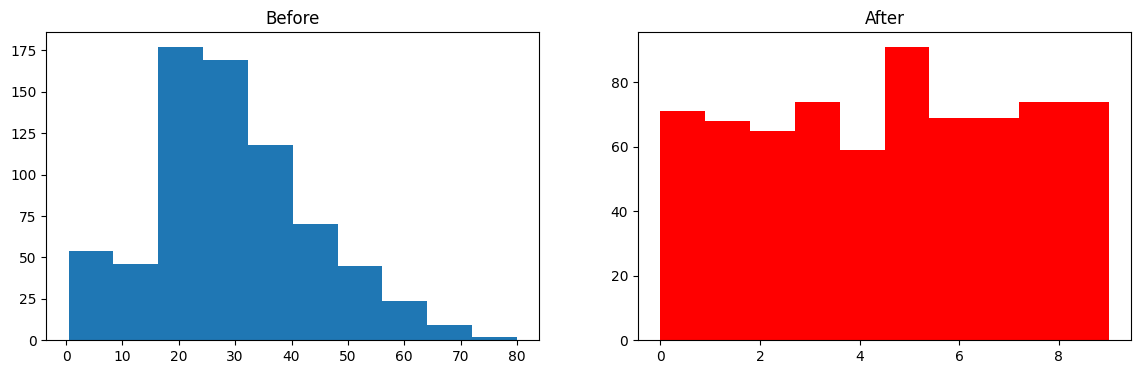

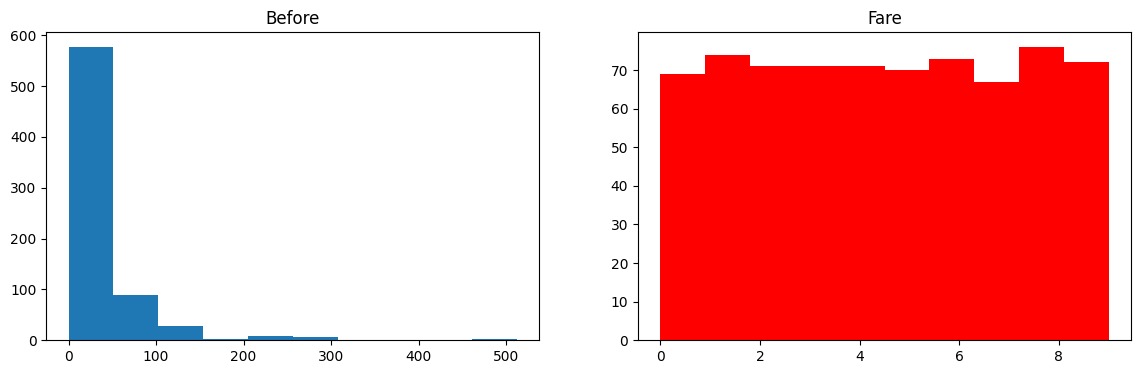

In [28]:
# Call the discretize function with 10 bins and 'quantile' strategy
discretize(10,'quantile')

0.6373043818466353


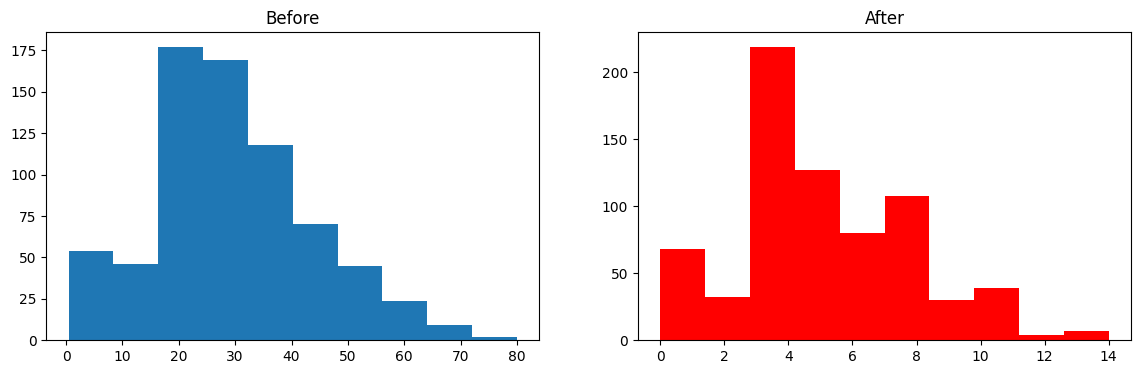

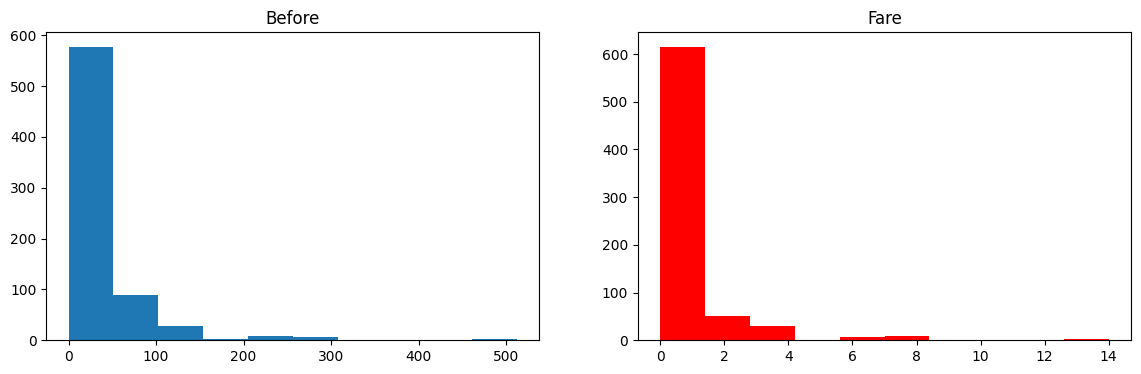

In [30]:
# Call the discretize function with 15 bins and 'uniform' strategy
discretize(15,'uniform')